# Regression Task: Curve Fitting

Neural networks aren't just for classification. In this notebook, we will use the library to approximate a function based on noisy data using **Mean Squared Error (MSE)** loss.

In [22]:
import matplotlib.pyplot as plt
from diy_neural_net import NeuralNetwork, utils
from diy_neural_net.Layers import Dense
from diy_neural_net.Activations import ReLU, Tanh
from diy_neural_net.Losses import MSELoss
from diy_neural_net.Optimizer import Adam
from diy_neural_net.DeviceSelector import get_numpy, is_gpu_available

np = get_numpy()
print(f"Hardware Acceleration: {'GPU (CuPy)' if is_gpu_available() else 'CPU (NumPy)'}")

Hardware Acceleration: GPU (CuPy)


## 1. Generate Synthetic Data
We create a noisy linear relationship. The network will try to find the line of best fit.

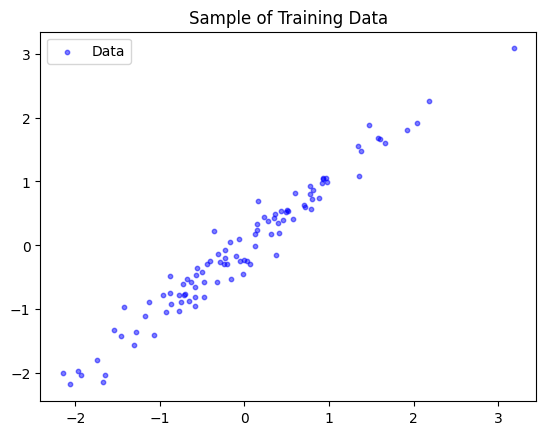

In [23]:
X, y = utils.generate_regression_data(n_samples=3000, n_features=1, noise=0.2, np=np)

X_train, X_test, y_train, y_test = utils.train_test_split(X, y, test_size=0.2)

X_plot = X_train.get() if hasattr(X_train, "get") else X_train
y_plot = y_train.get() if hasattr(y_train, "get") else y_train

plt.scatter(X_plot[0, :100], y_plot[0, :100], s=10, c="blue", alpha=0.5, label="Data")
plt.title("Sample of Training Data")
plt.legend()
plt.show()

## 2. Regression Model
For regression:
1. The output layer usually has no activation (linear).
2. The loss function is **MSELoss**.

In [24]:
model = NeuralNetwork.Sequential(
    [
        Dense(1, 64, initializer="he"),
        ReLU(),
        Dense(64, 32, initializer="he"),
        ReLU(),
        Dense(32, 1, initializer="random"),  # Output layer: 1 continuous value
    ]
)

model.set_loss(MSELoss())

In [25]:
optimizer = Adam(model, lr=0.01)

history = model.fit(
    X_train=X_train,
    y_train=y_train,
    optimizer=optimizer,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
)
print(
    f"\nTime Elapsed : {history['Time_Elapsed']:.2F} seconds on : {'GPU' if is_gpu_available() else 'CPU'}\n"
)

Epoch : 0
Train Loss : 0.5672 Test Loss : 0.0891
Epoch : 10
Train Loss : 0.0540 Test Loss : 0.0490
Epoch : 20
Train Loss : 0.0582 Test Loss : 0.0730
Epoch : 30
Train Loss : 0.0460 Test Loss : 0.0451
Epoch : 40
Train Loss : 0.0455 Test Loss : 0.0649

Time Elapsed : 1.47 seconds on : GPU



## 3. Visualization
Let's compare the model's learned line against the true data.

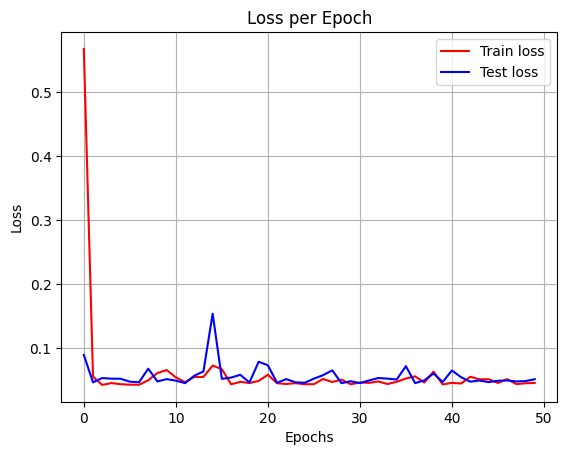

Regression task detected (Accuracy is 0). Skipping Accuracy plot.


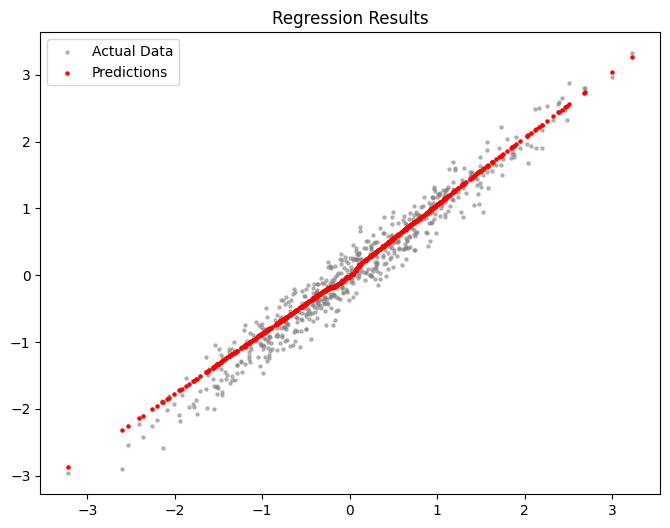

In [26]:
# Plot Loss
utils.plot_metrics(history)
# Plot Predictions
y_pred = model.predict(X_test)

# Move to CPU for plotting
X_test_cpu = utils.to_cpu(X_test)
y_test_cpu = utils.to_cpu(y_test)
y_pred_cpu = utils.to_cpu(y_pred)

plt.figure(figsize=(8, 6))
plt.scatter(X_test_cpu[0], y_test_cpu[0], s=5, c="gray", alpha=0.5, label="Actual Data")
plt.scatter(X_test_cpu[0], y_pred_cpu[0], s=5, c="red", label="Predictions")
plt.title("Regression Results")
plt.legend()
plt.show()